# Pillbox Analysis

In [1]:
from cavsim3d.analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
from cavsim3d.core.em_project import EMProject

%matplotlib widget
plt.rcParams['figure.dpi'] = 100

In [2]:
project_name = 'Pillbox_split'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

✅ Creating new project 'Pillbox_split' at C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\Pillbox_split


In [3]:
# # 1. Load and prepare geometry
# geo = STEPImporter(r"./pillbox.step", auto_build=False)
# geo.add_splitting_plane_at_x(0.0)
# geo.split()
#
# geo.show_split_preview()
# geo.build()
# geo.name_solids(port_axis='x')
#
# geo.generate_mesh(maxh=0.1)

In [4]:
# 1. Load and prepare geometry
geo = proj.import_geometry(r"./pillbox.step", unit='m', auto_build=False)
geo.add_splitting_plane_at_x(0.0)
geo.split()
geo.show_split_preview()
geo.build()
geo.name_solids(port_axis='x')

geo.generate_mesh() # after naming solids, must generate mesh but avoid rebuilding
geo.print_info()


STEP solids found:
  - 

Done splitting
Named 2 solids (1 unique materials):
  solid 0: ''
  solid 1: ''
Ports: 3 ports assigned by position (port1 ... port3)
Split sub-domains: ['subdomain1', 'subdomain2']
Done rebuilding
Displayed 2 solids with distinct colors
Displayed 1 splitting plane(s)


Named 2 solids (1 unique materials):
  solid 0: ''
  solid 1: ''
Ports: 3 ports assigned by position (port1 ... port3)
Split sub-domains: ['subdomain1', 'subdomain2']
Ports: 3 ports assigned by position (port1 ... port3)
Split sub-domains: ['subdomain1', 'subdomain2']

STEP Geometry Information
File: ./pillbox.step
Unit: m
Number of solids: 2
Is split: True
Number of splitting planes: 1
Plane positions (z): [-0.36000012]

Bounding Box:
  Min: (-0.7022, -0.3022, -0.3000)
  Max: (0.7022, 0.3022, 0.3000)
  Size: (1.4044, 0.6044, 0.6000)

NGSolve geometry built: True
Mesh generated: True


TraitError: The 'rotation' trait of a GridHelper instance contains an Enum of an Euler which expected any of ['XYZ', 'YZX', 'ZXY', 'XZY', 'YXZ', 'ZYX'], not the str 'xyz'.

In [5]:
geo.show('mesh')
geo.print_info()

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…


STEP Geometry Information
File: ./pillbox.step
Unit: m
Number of solids: 2
Is split: True
Number of splitting planes: 1
Plane positions (z): [-0.36000012]

Bounding Box:
  Min: (-0.7022, -0.3022, -0.3000)
  Max: (0.7022, 0.3022, 0.3000)
  Size: (1.4044, 0.6044, 0.6000)

NGSolve geometry built: True
Mesh generated: True


In [6]:
foms_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 20,
    'fmin': 1e-3,
    'fmax': 2,
    'solver_type': 'direct',
    # 'iterative_opts': {
    #     'precond': 'bddc',
    #     'maxsteps': 500,
    # },
    'rerun': True
}
foms_result = proj.fds.solve(config=foms_config)


Structure Topology
  Type: Compound structure
  Domains (2): ['subdomain1', 'subdomain2']
  Ports (3): ['port1', 'port2', 'port3']
  Mesh elements: 2095
  External Ports (2): ['port1', 'port3']
  Internal Ports (1): ['port2']

  Domain-Port Mapping:
    subdomain1: ['port1 (input)', 'port2 (internal)']
    subdomain2: ['port2 (internal)', 'port3 (output)']

Assembling Matrices...
Solving port eigenmodes...
Calculating Port Eigenmodes...
	port1 mode 0: TE_11 (cos), kc=18.4110, sigma=+1
	port1 mode 1: TE_11 (sin), kc=18.4110, sigma=+1
	port1 mode 2: TM_01, kc=24.0471, sigma=+1
	port2 mode 0: TE_11 (cos), kc=18.4110, sigma=+1
	port2 mode 1: TE_11 (sin), kc=18.4110, sigma=+1
	port2 mode 2: TM_01, kc=24.0471, sigma=+1
	port3 mode 0: TE_11 (cos), kc=18.4110, sigma=+1
	port3 mode 1: TE_11 (sin), kc=18.4110, sigma=+1
	port3 mode 2: TM_01, kc=24.0471, sigma=+1
Port eigenmodes complete: 9 total modes
eps values [1.0, 1.0]
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simula

In [7]:
proj.fds.plot_port_mode('port1', mode=0, component='abs')


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 0.8785 GHz


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Loaded CST S-parameters from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


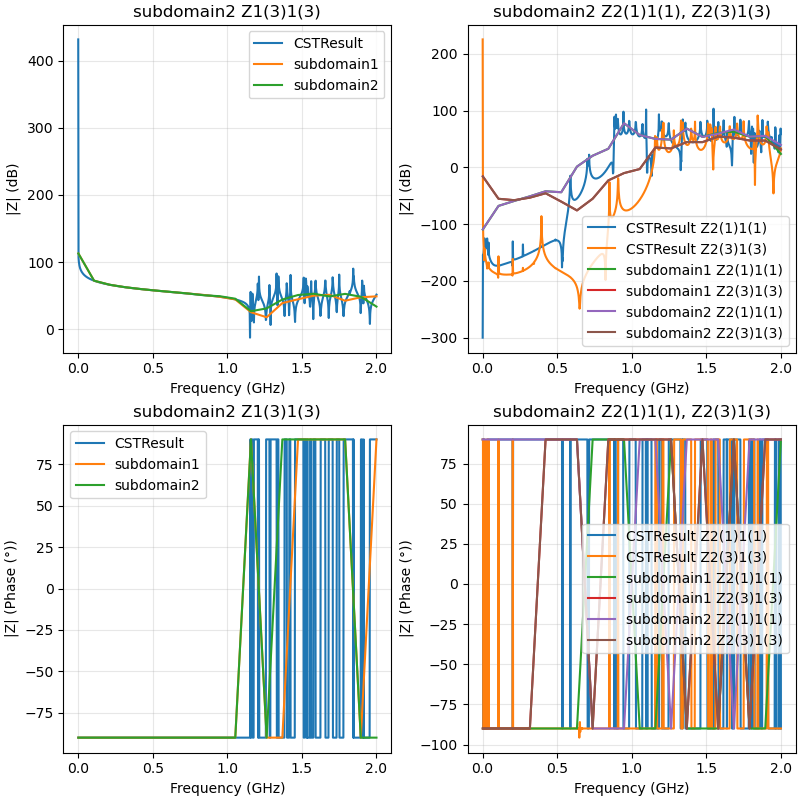

In [8]:
from cavsim3d.analytical.cst_result import CSTResult

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')
# plot comparison
which = [['1(3)1(3)'], ['2(1)1(1)', '2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1])
    proj.fds.foms.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.foms.plot_z(wh, plot_type='phase', ax=axs[idx+3])

# Reduce model orders

In [9]:
# Reduce model order
roms = proj.fds.foms.reduce(tol=1e-15)
# concat = proj.fds.fom.rom.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 2,
    'solver_type': 'direct' # <- changed to direct method, faster for smaller matrices
}
roms_result = roms.solve(config=roms_config) # solve reduced order model on more frequency samples


Model Order Reduction
Reduction complete: 62778 -> 240 DOFs (99.6% compression)
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\Pillbox_split\fds\port_modes\port_modes.pkl

ROM Solve: 0.001 - 2 GHz, 1000 samples


Loaded CST S-parameters from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


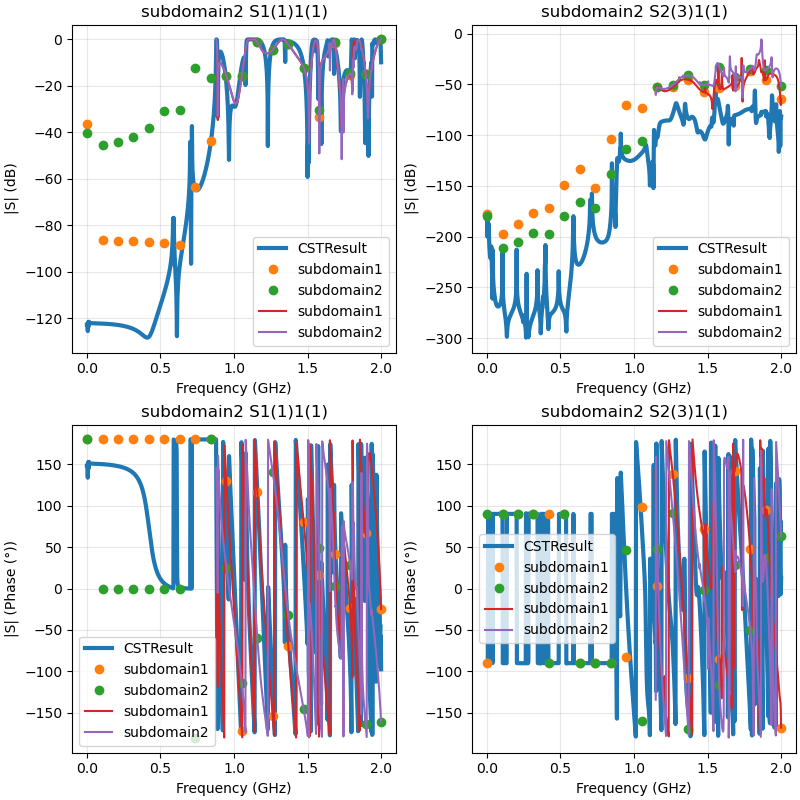

In [10]:
from cavsim3d.analytical.cst_result import CSTResult
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=3)
    proj.fds.foms.plot_s(wh, ax=axs[idx+1], marker='o', lw=0)
    roms.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    (proj.fds.
     foms.plot_s(wh, plot_type='phase', ax=axs[idx+3], marker='o', lw=0))
    roms.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

# Concatenation

In [11]:
concat_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 2,
    'solver_type': 'direct' # <- changed to direct method, faster for smaller matrices
}
concat = roms.concatenate()
concat_result = concat.solve(config=concat_config)


Concat Solve: 0.001 - 2 GHz, 1000 samples, system size 237
  Concat solve complete: 0.337s (1000 frequencies)


Loaded CST S-parameters from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


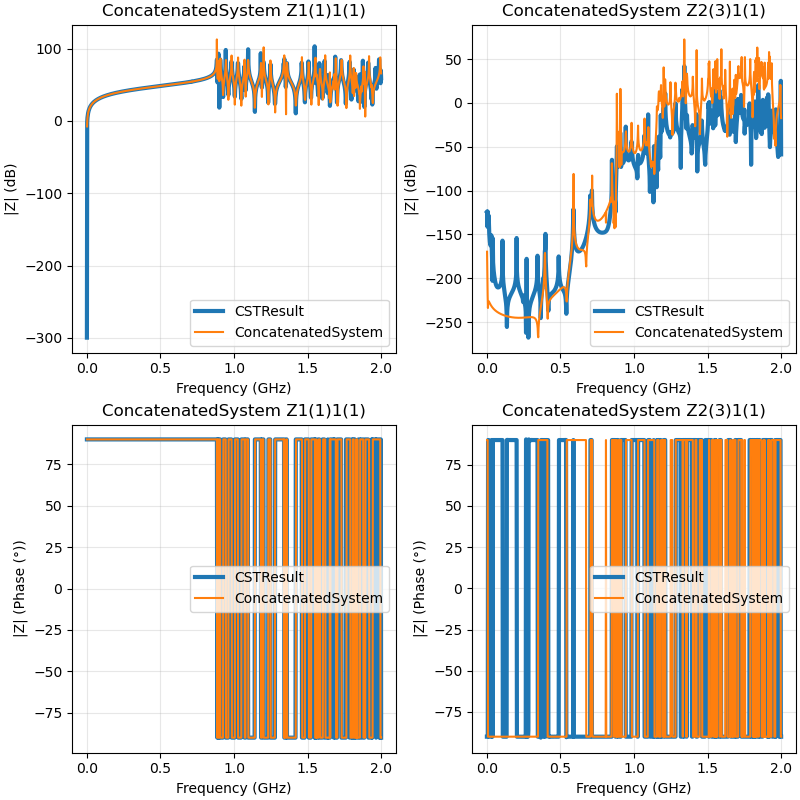

In [13]:
from cavsim3d.analytical.cst_result import CSTResult
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1], lw=3)
    concat.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    concat.plot_z(wh, plot_type='phase', ax=axs[idx+3])
plt.show()


Loaded CST S-parameters from: pillbox
  Frequency range: 0.0000 - 2.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


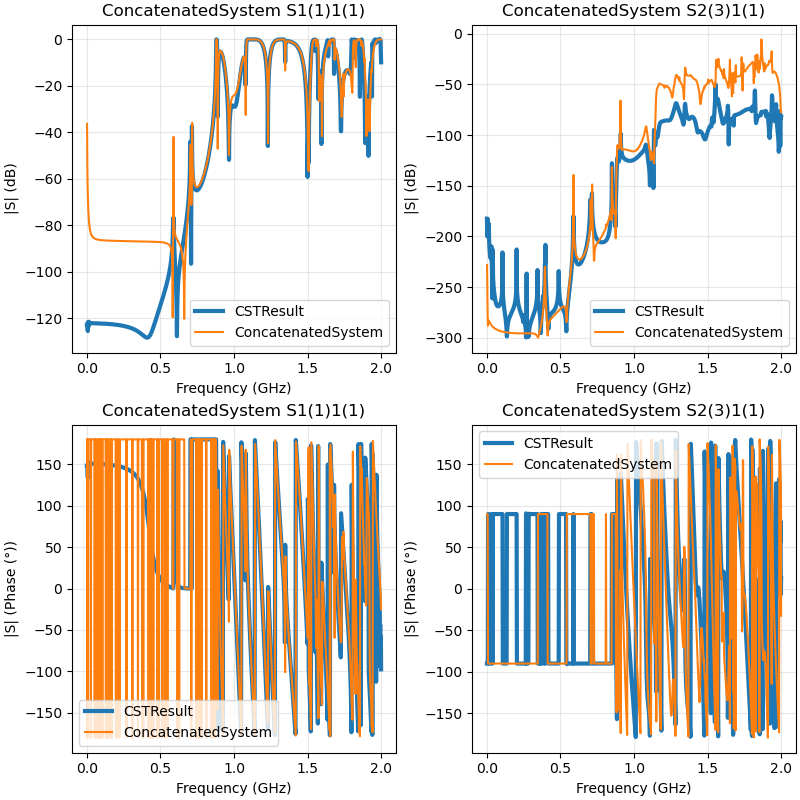

In [12]:
from cavsim3d.analytical.cst_result import CSTResult
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\pillbox')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(1)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=3)
    concat.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    concat.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()
